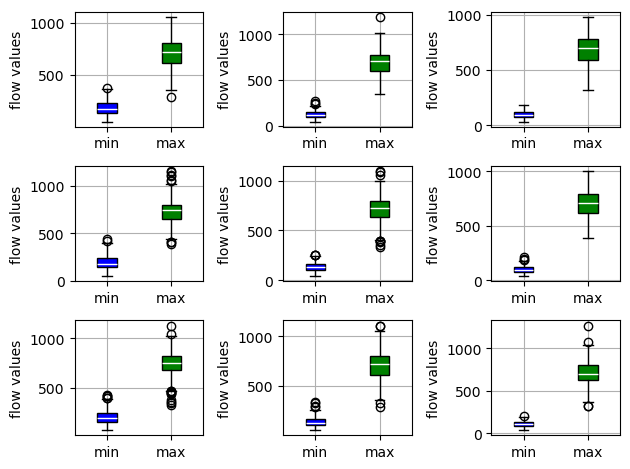

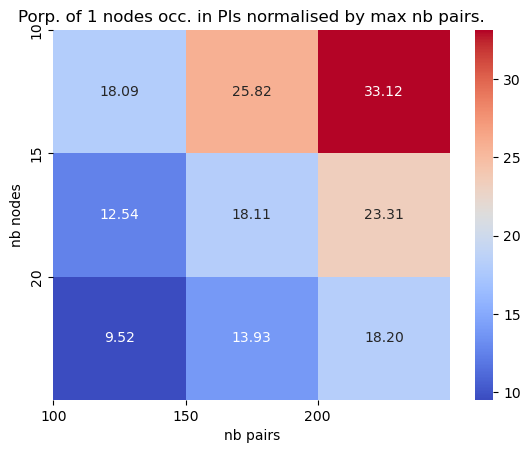

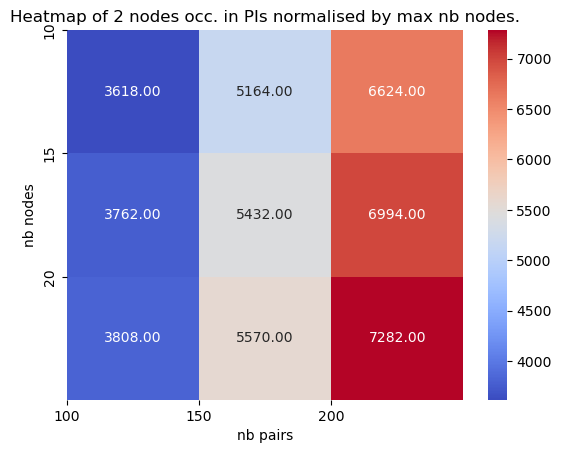

In [ ]:
import os

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from itertools import product

import pprint

import sys

os.chdir('C:\\Users\\HADDAM\\Documents\\Python Scripts\\multi_flow_decomp\\')
from utils.general_eval_msmd_metrics import instance_flow_proportion_shortest_paths, get_arcs, has_arc
from utils.graph_utils import out_degree, in_degree, get_arcs, get_nodes, get_neighbours, get_nb_nodes


# The parameters values for reading the files
ls_vals_nb_nodes = [100, 150, 200]

ls_vals_nb_pairs = [10, 15, 20]

ls_vals_degrees = [3, 4]

ls_param_vals = list(product(ls_vals_nb_nodes, ls_vals_nb_pairs, ls_vals_degrees))


# Dict inits
dir_path_instances = "data/simulated_data/complete_instances/node_pairs/small_world_like/capacity_factor=14/"


# Min an max flow vals
min_flow_vals_data, max_flow_vals_data = {}, {}
for nb_nodes, nb_all_pairs, des_degree in ls_param_vals:
    file_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"
    dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]

    # Constructing a boxplot showing how the minimal and maximal flow values are spread
    ls_min_fl_val = [min(mfd_instance.original_flow_values) 
                    for mfd_instance, _ in dict_instances.values()]
    
    ls_max_fl_val = [max(mfd_instance.original_flow_values) 
                    for mfd_instance, _ in dict_instances.values()]
    if (nb_nodes, nb_all_pairs) not in min_flow_vals_data:
        min_flow_vals_data[(nb_nodes, nb_all_pairs)] = ls_min_fl_val
    else:
        min_flow_vals_data[(nb_nodes, nb_all_pairs)].extend(ls_min_fl_val)

    if (nb_nodes, nb_all_pairs) not in max_flow_vals_data:
        max_flow_vals_data[(nb_nodes, nb_all_pairs)] = ls_max_fl_val
    else:
        max_flow_vals_data[(nb_nodes, nb_all_pairs)].extend(ls_max_fl_val)


fig, axs = plt.subplots(len(ls_vals_nb_nodes), len(ls_vals_nb_pairs))

for i in range(len(ls_vals_nb_nodes)):
    for j in range(len(ls_vals_nb_pairs)):
        nb_nodes, nb_all_pairs = ls_vals_nb_nodes[i], ls_vals_nb_pairs[j]
        box = axs[i, j].boxplot(min_flow_vals_data[(nb_nodes, nb_all_pairs)], 
                        patch_artist = True,
                        widths = 0.3,
                        positions = [0])
        box['boxes'][0].set_facecolor("blue")
        box['medians'][0].set_color("white")

        box = axs[i, j].boxplot(max_flow_vals_data[(nb_nodes, nb_all_pairs)], 
                        patch_artist = True,
                        widths = 0.3,
                        positions = [1])
        box['boxes'][0].set_facecolor("green")
        box['medians'][0].set_color("white")
        axs[i, j].set_xticks([0, 1], ['min', 'max'])
        axs[i, j].set_ylabel("flow values")
        axs[i, j].grid(visible = True)
plt.tight_layout()




# Constructing a heatmap showing how many nodes are point of interests 
# (sources or destinations)
max_nb_all_pairs = 20
keys_cpt_nbpis = list(product(ls_vals_nb_nodes, ls_vals_nb_pairs))
#cpt_nbpis = {(params):[0 for _ in range(max_nb_all_pairs+1)] 
#                            for params in ls_param_vals}
cpt_nbpis = {}
for nb_nodes, nb_all_pairs, des_deg in ls_param_vals:
    file_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"
    dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]
    
    for id_instance, _, _ in dict_instances:
        mfd_instance, multi_flow = dict_instances[id_instance, True, True]
        cpt_node_pis = 0
        for node in get_nodes(mfd_instance.original_adj_mat):
            nb_times_pis = len([1 for s, t in mfd_instance.pairs if node == s or node == t])
            if len(nb_times_pis) > 0: cpt_node_pis += 1

        if (nb_nodes, nb_all_pairs) not in cpt_nbpis:
            cpt_nbpis[(nb_nodes, nb_all_pairs)] = [cpt_node_pis/nb_nodes]
        else:
            cpt_nbpis[(nb_nodes, nb_all_pairs)].append(cpt_node_pis/nb_nodes)

tresh_nb_pis = 1
prop_pis_sup_treshold = [[sum(cpt_nbpis[(nb_nodes, nb_all_pairs)][tresh_nb_pis:])/(2*nb_nodes) 
                            for nb_all_pairs in ls_vals_nb_pairs] 
                                for nb_nodes in ls_vals_nb_nodes]

plt.figure()

sns.heatmap(
    prop_pis_sup_treshold,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)
plt.xticks(list(range(len(ls_vals_nb_nodes))), ls_vals_nb_nodes)
plt.yticks(list(range(len(ls_vals_nb_pairs))), ls_vals_nb_pairs)

plt.title("Porp. of "+str(tresh_nb_pis)+" nodes occ. in PIs normalised by max nb pairs.")
plt.xlabel("nb pairs")
plt.ylabel("nb nodes")




# How many arcs are traversed by how many flows
max_nb_all_pairs = 20
keys_cpt_arc_pairs = list(product(ls_vals_nb_nodes, ls_vals_nb_pairs))
cpt_arc_pairs = {(params):[0 for _ in range(max_nb_all_pairs+1)] 
                            for params in keys_cpt_nbpis}
for nb_nodes, nb_all_pairs, des_degree in ls_param_vals:
    file_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"
    dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]
    
    for id_instance, _, _ in dict_instances:
        mfd_instance, multi_flow = dict_instances[id_instance, True, True]
        for u, v in get_arcs(mfd_instance.original_adj_mat):
            nb_pass_flows = sum(int(multi_flow[i][u][v] > 0) 
                                    for i in range(len(multi_flow)))
            cpt_arc_pairs[(nb_nodes, nb_all_pairs)][nb_pass_flows] += 1


tresh_nb_arcs = 2
prop_arcs_sup_treshold = [[sum(cpt_nbpis[(nb_nodes, nb_all_pairs)][tresh_nb_pis:]) 
                            for nb_all_pairs in ls_vals_nb_pairs] 
                                for nb_nodes in ls_vals_nb_nodes]

plt.figure()

sns.heatmap(
    prop_arcs_sup_treshold,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)
plt.xticks(list(range(len(ls_vals_nb_nodes))), ls_vals_nb_nodes)
plt.yticks(list(range(len(ls_vals_nb_pairs))), ls_vals_nb_pairs)

plt.title("Heatmap of "+str(tresh_nb_arcs)+" nodes occ. in PIs normalised by max nb nodes.")
plt.xlabel("nb pairs")
plt.ylabel("nb nodes")



plt.show()

The degree list 
100  (2.46, 0.77) (2.92, 0.89)  (3.09, 1.03) (3.82, 1.02)
150  (2.41, 0.79) (2.9, 0.95)  (2.95, 1.02) (3.74, 1.05)
200  (2.37, 0.64) (2.89, 1.0)  (2.96, 0.96) (3.69, 1.11)
Box plots  32 443
Box plots  289 1267
Number of instances for which %\ of arcs with more than one flow  70 0.5
200 15 3 79
{0: [90, 69], 1: [95, 145, 147], 2: [124, 106, 120], 3: [81, 28, 192, 97], 4: [86, 186, 187, 51], 5: [99], 6: [], 7: [95, 79, 84], 8: [], 9: [85, 189], 10: [54, 39], 11: [103, 77, 47], 12: [185], 13: [22, 15, 181, 60], 14: [96, 99], 15: [105, 13, 34], 16: [118], 17: [115], 18: [], 19: [35, 174, 56, 136], 20: [58, 33, 173], 21: [145], 22: [34, 169, 13, 5, 82], 23: [83, 102, 7], 24: [27, 137], 25: [69], 26: [76], 27: [192, 18, 193], 28: [3, 75, 172, 86], 29: [], 30: [119, 76, 38, 159], 31: [173, 131, 168], 32: [138, 88, 187], 33: [20, 125, 147, 164], 34: [76], 35: [156], 36: [], 37: [68], 38: [99, 143, 30, 159], 39: [139, 191], 40: [108, 140, 158], 41: [], 42: [], 43: [197, 112], 4

SystemExit: 

c:\Users\HADDAM\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3465: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


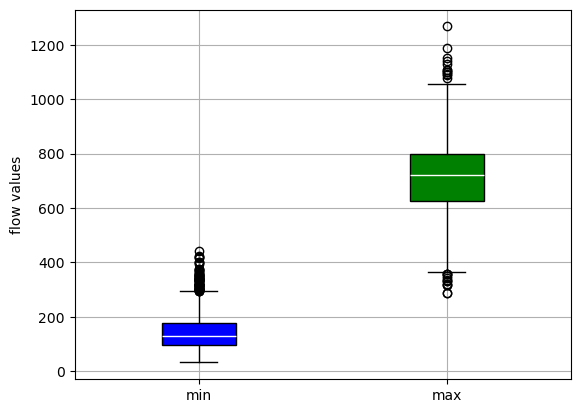

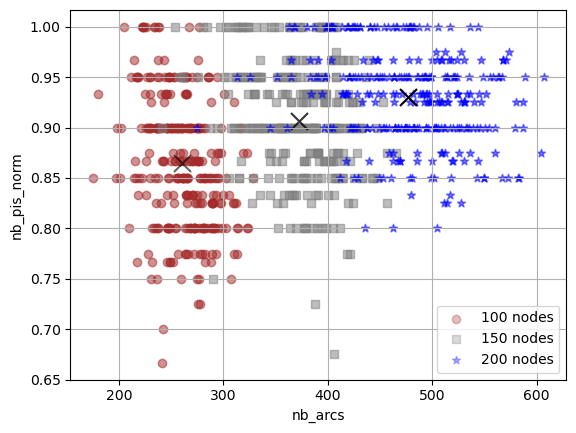

In [8]:
import os

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from itertools import product

import pprint

import sys

import numpy as np

os.chdir('C:\\Users\\HADDAM\\Documents\\Python Scripts\\multi_flow_decomp\\')
from utils.general_eval_msmd_metrics import instance_flow_proportion_shortest_paths, get_arcs, has_arc
from utils.graph_utils import out_degree, in_degree, get_arcs, get_nodes, get_neighbours, get_nb_nodes


# The parameters values for reading the files
ls_vals_nb_nodes = [100, 150, 200]

ls_vals_nb_pairs = [10, 15, 20]

ls_vals_degrees = [3, 4]

ls_param_vals = list(product(ls_vals_nb_nodes, ls_vals_nb_pairs, ls_vals_degrees))


# Dict inits
dir_path_instances = "data/simulated_data/complete_instances/node_pairs/small_world_like/capacity_factor=14/"

# Save path
save_path = "results/simulated/MFDS_vs_RL/generated_instances/" 



# Mean degrees
dict_mean_degrees = {}
for nb_nodes, nb_all_pairs, des_degree in ls_param_vals:
    file_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"
    dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]

    for mfd_instance, _ in dict_instances.values():
        # Constructing a boxplot showing how the minimal and maximal flow values are spread
        nodes = get_nodes(mfd_instance.adj_mat)
        ls_inst_degrees = [len(get_neighbours(mfd_instance.adj_mat, node)) for node in nodes if len(get_neighbours(mfd_instance.adj_mat, node)) > 0]
        mean_deg = np.mean(ls_inst_degrees)
        std_deg = np.std(ls_inst_degrees, ddof = 1)
    
        # List of mean degrees
        if (nb_nodes, des_degree) in dict_mean_degrees:
            dict_mean_degrees[(nb_nodes, des_degree)].append((round(float(mean_deg), 2), 
                                                              round(float(std_deg), 2)))
        else:
            dict_mean_degrees[(nb_nodes, des_degree)] = [(round(float(mean_deg), 2), 
                                                          round(float(std_deg), 2))]

print("The degree list ")
for nb_nodes in ls_vals_nb_nodes:
    str_ = str(nb_nodes)
    for des_degree in ls_vals_degrees:
        dict_mean_degrees[(nb_nodes, des_degree)].sort(key = lambda x : (x[0], x[1]))
        str_ += "  "+str(min(dict_mean_degrees[(nb_nodes, des_degree)]))+" "+str(max(dict_mean_degrees[(nb_nodes, des_degree)]))
    print(str_)        



# Min an max flow vals
min_flow_vals_data, max_flow_vals_data = [], []
for nb_nodes, nb_all_pairs, des_degree in ls_param_vals:
    file_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"
    dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]

    # Constructing a boxplot showing how the minimal and maximal flow values are spread
    ls_min_fl_val = [min(mfd_instance.original_flow_values) 
                    for mfd_instance, _ in dict_instances.values()]
    
    ls_max_fl_val = [max(mfd_instance.original_flow_values) 
                    for mfd_instance, _ in dict_instances.values()]
    
    min_flow_vals_data.extend(ls_min_fl_val)
    max_flow_vals_data.extend(ls_max_fl_val)

print("Box plots ", min(min_flow_vals_data), max(min_flow_vals_data))

print("Box plots ", min(max_flow_vals_data), max(max_flow_vals_data))

fig = plt.figure()
box = plt.boxplot(min_flow_vals_data, 
                  patch_artist = True,
                  widths = 0.3,
                  positions = [0])
box['boxes'][0].set_facecolor("blue")
box['medians'][0].set_color("white")

box = plt.boxplot(max_flow_vals_data, 
                  patch_artist = True,
                  widths = 0.3,
                  positions = [1])
box['boxes'][0].set_facecolor("green")
box['medians'][0].set_color("white")
plt.xticks([0, 1], ['min', 'max'])
plt.ylabel("flow values")
plt.grid(visible = True)
if save_path is not None:
    fig.savefig(os.path.join(save_path, 
                             "min_max_flow_distributions"), 
                             bbox_inches='tight', 
                             pad_inches = 0)




# Number of points of interests normalised by twice the number of O/D pairs
dict_nb_pis_norm = {}
for nb_nodes, nb_all_pairs, des_deg in ls_param_vals:
    file_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"
    dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]
    
    for id_instance, _, _ in dict_instances:
        mfd_instance, multi_flow = dict_instances[id_instance, True, True]
        pairs = mfd_instance.pairs
        cpt_node_pis = 0
        nb_pis = len({s for s, t in mfd_instance.pairs} | {t for s, t in mfd_instance.pairs})
        nb_pairs = len(mfd_instance.pairs)
        #eff_nb_nodes = len([node for node in get_nodes(mfd_instance.adj_mat) if in_degree(mfd_instance.adj_mat, node) + out_degree(mfd_instance.adj_mat, node) > 0])
        if nb_nodes in dict_nb_pis_norm:
            if "xs" in dict_nb_pis_norm[nb_nodes] and "ys" in dict_nb_pis_norm[nb_nodes]:
                dict_nb_pis_norm[nb_nodes]["xs"].append(len(get_arcs(mfd_instance.adj_mat)))
                dict_nb_pis_norm[nb_nodes]["ys"].append(nb_pis/(2*nb_pairs))
            else:
                dict_nb_pis_norm[nb_nodes]["xs"] = [len(get_arcs(mfd_instance.adj_mat))]
                dict_nb_pis_norm[nb_nodes]["ys"] = [nb_pis/(2*nb_pairs)]
        else:
            dict_nb_pis_norm[nb_nodes] = {"xs":[len(get_arcs(mfd_instance.adj_mat))],
                                          "ys":[nb_pis/(2*nb_pairs)]}

fig = plt.figure()
ls_markers = ["o", "s", "*"]
ls_colors = ["brown", "grey", "blue"]
alphas = [0.6, 0.8, 1.0]
for i in range(len(ls_vals_nb_nodes)):
    nb_nodes = ls_vals_nb_nodes[i]
    plt.scatter(dict_nb_pis_norm[nb_nodes]["xs"], 
                dict_nb_pis_norm[nb_nodes]["ys"],
                c=ls_colors[i],
                marker=ls_markers[i],
                label = str(nb_nodes)+" nodes",
                alpha=0.3)
    plt.scatter(np.mean(dict_nb_pis_norm[nb_nodes]["xs"]), 
                np.mean(dict_nb_pis_norm[nb_nodes]["ys"]),
                c="black",
                marker="x",
                s = 150,
                alpha = alphas[i])

plt.legend(loc="lower right")
plt.xlabel("nb_arcs")
plt.ylabel("nb_pis_norm")
plt.grid(visible = True)
if save_path is not None:
    fig.savefig(os.path.join(save_path, 
                             "nodes_in_pis"), 
                             bbox_inches='tight', 
                             pad_inches = 0)



# NUmber of arcs traversed by more than one flow
dict_nb_fls_norm, tableau = {}, []
nb_instances_sup_tresh, treshold = 0, 0.5
for nb_nodes, nb_all_pairs, des_deg in ls_param_vals:
    file_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"
    dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]
    
    for id_instance, _, _ in dict_instances:
        mfd_instance, multi_flow = dict_instances[id_instance, True, True]
        pairs = mfd_instance.pairs
        arcs, nb_arcs_mulflow = get_arcs(mfd_instance.adj_mat), 0
        for u, v in arcs:
            nb_flows = len([1 for i in range(len(multi_flow)) if multi_flow[i][u][v] > 0])
            if nb_flows > 1: nb_arcs_mulflow += 1
        
        if nb_arcs_mulflow/len(arcs) < treshold:
            nb_instances_sup_tresh += 1
            tableau.append((nb_nodes, 
                            nb_all_pairs, 
                            des_deg,
                            id_instance,        
                            mfd_instance.adj_mat, 
                            len(get_arcs(mfd_instance.adj_mat)), 
                            nb_arcs_mulflow/len(arcs)))
        
        if nb_all_pairs in dict_nb_fls_norm:
            if "xs" in dict_nb_fls_norm[nb_all_pairs] and "ys" in dict_nb_fls_norm[nb_all_pairs]:
                dict_nb_fls_norm[nb_all_pairs]["xs"].append(len(get_arcs(mfd_instance.adj_mat)))
                dict_nb_fls_norm[nb_all_pairs]["ys"].append(nb_arcs_mulflow/len(arcs))
            else:
                dict_nb_fls_norm[nb_all_pairs]["xs"] = [len(get_arcs(mfd_instance.adj_mat))]
                dict_nb_fls_norm[nb_all_pairs]["ys"] = [nb_arcs_mulflow/len(arcs)]
        else:
            dict_nb_fls_norm[nb_all_pairs] = {"xs":[len(get_arcs(mfd_instance.adj_mat))],
                                          "ys":[nb_arcs_mulflow/len(arcs)]}


print("Number of instances for which %\ of arcs with more than one flow ", 
      nb_instances_sup_tresh, treshold)
searched = [] 
for elem in tableau: 
    if (elem[-2], elem[-1]) == (417, 0.49640287769784175):
        searched.append(elem)


for elem in searched:
    print(elem[0], elem[1], elem[2], elem[3])
    print(elem[4])

print("----------------------------")

file_path = dir_path_instances+"nb_nodes="+str(200)+"_nb_pairs="+str(15)+"_nb_neighbours="+str(3)+".npy"
dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]
print(dict_instances[(0, True, True)][0].adj_mat)


file_path = dir_path_instances+"nb_nodes="+str(200)+"_nb_pairs="+str(15)+"_nb_neighbours="+str(4)+".npy"
dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]
print(dict_instances[(0, True, True)][0].adj_mat)

sys.exit()

fig = plt.figure()
ls_markers = ["o", "s", "*"]
ls_colors = ["brown", "grey", "blue"]
alphas = [0.6, 0.8, 1.0]
for i in range(len(ls_vals_nb_pairs)):
    nb_all_pairs = ls_vals_nb_pairs[i]
    plt.scatter(dict_nb_fls_norm[nb_all_pairs]["xs"], 
                dict_nb_fls_norm[nb_all_pairs]["ys"],
                c=ls_colors[i],
                marker=ls_markers[i],
                label = str(nb_all_pairs)+" pairs",
                alpha=0.3)
    plt.scatter(np.mean(dict_nb_fls_norm[nb_all_pairs]["xs"]), 
                np.mean(dict_nb_fls_norm[nb_all_pairs]["ys"]),
                c="black",
                marker="x",
                s = 150,
                alpha = alphas[i])

plt.legend(loc="lower right")
plt.xlabel("nb_arcs")
plt.ylabel("nb_fl_norm")
plt.grid(visible = True)
if save_path is not None:
    fig.savefig(os.path.join(save_path, 
                             "flows_in_arcs"), 
                             bbox_inches='tight', 
                             pad_inches = 0)


plt.show()

In [ ]:
import os

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from itertools import product

import pprint

import sys

import numpy as np

os.chdir('C:\\Users\\HADDAM\\Documents\\Python Scripts\\multi_flow_decomp\\')
from utils.general_eval_msmd_metrics import instance_flow_proportion_shortest_paths, get_arcs, has_arc
from utils.graph_utils import out_degree, in_degree, get_arcs, get_nodes, get_neighbours, get_nb_nodes


nb_nodes, nb_all_pairs, des_degree = 100, 10, 3
dir_path_instances = "data/simulated_data/complete_instances/node_pairs/small_world_like/capacity_factor=14/nb_neighbours_n_distance_n_shuffle_tresh/"
file_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"
dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]
ls_ = []
for id_instance, _, _ in dict_instances:
    mfd_instance, multi_flow = dict_instances[id_instance, True, True]
    pairs = mfd_instance.pairs
    arcs, nb_arcs_mulflow = get_arcs(mfd_instance.adj_mat), 0
    ls_.append((id_instance, des_degree, len(arcs), mfd_instance))

for i in range(len(ls_)):
    for j in range(i+1, len(ls_)):
        found = False
        if ls_[i][1] == ls_[j][1]:
            print(ls_[i])
            print(ls_[j])
            print(ls_[i][2].adj_mat)
            print(ls_[j][2].adj_mat)
            found = True
            break
    if found: break


#print(ls_)

"""
nb_nodes, nb_all_pairs, des_degree = 100, 10, 3
dir_path_instances = "data/simulated_data/complete_instances/node_pairs/small_world_like/capacity_factor=14/nb_neighbours_n_distance_n_shuffle_tresh/"
file_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"
dict_instances = np.load(file_path, allow_pickle=True).flatten()[0]

for id_instance, _, _ in dict_instances:
    mfd_instance, multi_flow = dict_instances[id_instance, True, True]
    pairs = mfd_instance.pairs
    arcs, nb_arcs_mulflow = get_arcs(mfd_instance.adj_mat), 0
    for u, v in arcs:
        nb_flows = len([1 for i in range(len(multi_flow)) if multi_flow[i][u][v] > 0])
        if nb_flows > 1: nb_arcs_mulflow += 1
    
    if nb_arcs_mulflow/len(arcs) < treshold:
        nb_instances_sup_tresh += 1
        tableau.append((nb_nodes, 
                        nb_all_pairs, 
                        des_deg,
                        id_instance,        
                        mfd_instance.adj_mat, 
                        len(get_arcs(mfd_instance.adj_mat)), 
                        nb_arcs_mulflow/len(arcs)))
"""

(2, 175, <msmd.multi_flow_desag_instance_utils.MultiFlowDesagInstance object at 0x0000013B421DAF10>)
(77, 175, <msmd.multi_flow_desag_instance_utils.MultiFlowDesagInstance object at 0x0000013B5207AF10>)
{0: [50, 22, 18], 1: [], 2: [73, 79, 36], 3: [99], 4: [21, 22], 5: [52, 91, 80, 7], 6: [27, 50, 92], 7: [20, 37], 8: [], 9: [], 10: [79, 97], 11: [69, 12], 12: [36, 45, 11, 80], 13: [], 14: [], 15: [19], 16: [], 17: [33], 18: [93, 0], 19: [89, 42], 20: [80, 7], 21: [22, 93, 4], 22: [21, 4, 0], 23: [], 24: [], 25: [], 26: [55, 92, 60], 27: [6, 78], 28: [65, 53, 30, 66, 88], 29: [], 30: [28, 55], 31: [], 32: [51, 89, 49], 33: [68], 34: [99, 45, 91], 35: [], 36: [68, 12, 75, 2], 37: [7, 41], 38: [84, 45, 44, 3], 39: [49], 40: [], 41: [69, 37], 42: [18, 59, 0, 15, 19], 43: [42, 53, 60], 44: [84, 38], 45: [97, 38, 34], 46: [68, 81], 47: [39], 48: [76], 49: [32, 82], 50: [4, 0, 6], 51: [88, 32, 96], 52: [7], 53: [28, 96], 54: [78, 65], 55: [26, 30], 56: [70], 57: [], 58: [], 59: [53], 60: [53

'\nnb_nodes, nb_all_pairs, des_degree = 100, 10, 3\ndir_path_instances = "data/simulated_data/complete_instances/node_pairs/small_world_like/capacity_factor=14/nb_neighbours_n_distance_n_shuffle_tresh/"\nfile_path = dir_path_instances+"nb_nodes="+str(nb_nodes)+"_nb_pairs="+str(nb_all_pairs)+"_nb_neighbours="+str(des_degree)+".npy"\ndict_instances = np.load(file_path, allow_pickle=True).flatten()[0]\n\nfor id_instance, _, _ in dict_instances:\n    mfd_instance, multi_flow = dict_instances[id_instance, True, True]\n    pairs = mfd_instance.pairs\n    arcs, nb_arcs_mulflow = get_arcs(mfd_instance.adj_mat), 0\n    for u, v in arcs:\n        nb_flows = len([1 for i in range(len(multi_flow)) if multi_flow[i][u][v] > 0])\n        if nb_flows > 1: nb_arcs_mulflow += 1\n    \n    if nb_arcs_mulflow/len(arcs) < treshold:\n        nb_instances_sup_tresh += 1\n        tableau.append((nb_nodes, \n                        nb_all_pairs, \n                        des_deg,\n                        id_in